# Assignment 3 - Sarsa

**Frozen Lake - 4x5 Gridworld · Summer Semester 2026**

| | |
|---|---|
| **Name** | `Nihat Garibli` |
| **ID** | `5425819` |

Repeat Assignment 2 with the **Sarsa** algorithm: on-policy TD(0) control with an ε-decay (GLIE) schedule and a constant step size α. The same three figures are required: V\*, Q\* and π\*.

In [5]:
# gymnasium is pre-installed on Colab; install it only if it is missing.
try:
    import gymnasium  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gymnasium"])

import time

import numpy as np
import gymnasium as gym
from gymnasium.spaces import Discrete

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="white")

## 1. The environment

```
 S  F  F  F  F        states  0.. 4
 F  F  F  H  F        states  5.. 9   (hole at state 8)
 F  F  F  F  F        states 10..14
 H  F  F  F  G        states 15..19   (hole at 15, goal at 19)
```

Exactly as specified in the assignment sheet:

| Setting | Value |
|---|---|
| Step reward (**every** transition) | −0.08 |
| Goal / hole | +1 / −1, **added on top** of the step reward |
| P(intended direction) | 0.8 |
| P(slip to each perpendicular side) | 0.1 + 0.1 |
| Walls | rigid - the agent stays in place |
| Discount γ | 0.95 |
| Start state | uniformly random over the 17 non-terminal squares |

Actions: `0 = ← (W)`, `1 = ↓ (S)`, `2 = → (E)`, `3 = ↑ (N)`.

The step cost is what makes the task interesting: dawdling is expensive, so the
optimal policy has to trade off the **shortest** path against the **safest** path
around the two holes.

The environment exposes the full model as
`P[s][a] = [(prob, next_state, reward, terminated), ...]`, which is what the
Dynamic-Programming methods need; the model-free methods only use
`reset()` / `step()`.

In [6]:
# ---- constants, taken directly from the assignment sheet -------------------
GAMMA = 0.95
STEP_REWARD = -0.08
GOAL_REWARD = 1.0
HOLE_REWARD = -1.0
SLIP_PROB = 0.2

ACTION_ARROWS = ["←", "↓", "→", "↑"]          # left, down, right, up
ACTION_NAMES = ["W (left)", "S (down)", "E (right)", "N (up)"]

SEED = 0

# Filled in by the algorithms; used for the timing / iteration tables.
RUN_STATS = {}

# Module level RNG, so that a whole run is reproducible via set_seed().
RNG = np.random.default_rng(SEED)


def set_seed(seed):
    """Seed the module RNG (used by the epsilon-greedy behaviour policy)."""
    global RNG
    RNG = np.random.default_rng(seed)

In [7]:
class CustomFrozenLakeEnv(gym.Env):
    """A customised 4x5 FrozenLake that follows the gymnasium Env API.

    The full model (transition probabilities and rewards) is exposed through
    ``self.P[s][a] = [(prob, next_state, reward, terminated), ...]`` which is
    exactly what the Dynamic Programming algorithms of Assignment 1 need.
    """

    metadata = {"render_modes": ["ansi"], "render_fps": 4}

    def __init__(
        self,
        map_name="4x5",
        is_slippery=True,
        slip_prob=SLIP_PROB,
        step_reward=STEP_REWARD,
        goal_reward=GOAL_REWARD,
        hole_reward=HOLE_REWARD,
        random_start=True,
        render_mode=None,
    ):
        self.map_name = map_name
        self.is_slippery = is_slippery
        self.slip_prob = slip_prob
        self.step_reward = step_reward
        self.goal_reward = goal_reward
        self.hole_reward = hole_reward
        self.random_start = random_start
        self.render_mode = render_mode

        #  S F F F F
        #  F F F H F
        #  F F F F F
        #  H F F F G
        self.desc = np.asarray(["SFFFF", "FFFHF", "FFFFF", "HFFFG"], dtype="c")

        self.nrow, self.ncol = self.desc.shape
        self.nA = 4
        self.nS = self.nrow * self.ncol

        flat = self.desc.reshape(-1)
        self.terminal_states = np.array([bytes(c) in b"GH" for c in flat])
        self.hole_states = np.array([bytes(c) == b"H" for c in flat])
        self.goal_states = np.array([bytes(c) == b"G" for c in flat])
        # Episodes start in any non-terminal square (assignment: random start state).
        self.start_states = np.flatnonzero(~self.terminal_states)

        self.P = {s: {a: [] for a in range(self.nA)} for s in range(self.nS)}
        self._init_transitions()
        self._build_sampling_tables()

        self.observation_space = Discrete(self.nS)
        self.action_space = Discrete(self.nA)

        self.s = int(self.start_states[0])

    # ------------------------------------------------------------------ #
    # geometry helpers
    # ------------------------------------------------------------------ #
    def to_s(self, row, col):
        return row * self.ncol + col

    def inc(self, row, col, a):
        """Move one square in direction ``a``; the walls are rigid."""
        if a == 0:      # left  (W)
            col = max(col - 1, 0)
        elif a == 1:    # down  (S)
            row = min(row + 1, self.nrow - 1)
        elif a == 2:    # right (E)
            col = min(col + 1, self.ncol - 1)
        elif a == 3:    # up    (N)
            row = max(row - 1, 0)
        return (row, col)

    def _reward(self, newletter):
        """Step cost on every transition, plus the terminal bonus / penalty."""
        r = self.step_reward
        if newletter == b"G":
            r += self.goal_reward
        elif newletter == b"H":
            r += self.hole_reward
        return float(r)

    # ------------------------------------------------------------------ #
    # the model  P[s][a] -> [(prob, s', r, done), ...]
    # ------------------------------------------------------------------ #
    def _init_transitions(self):
        for row in range(self.nrow):
            for col in range(self.ncol):
                s = self.to_s(row, col)
                letter = self.desc[row, col]
                for a in range(self.nA):
                    li = self.P[s][a]
                    if bytes(letter) in b"GH":
                        # Absorbing terminal state: no further reward.
                        li.append((1.0, s, 0.0, True))
                        continue

                    if self.is_slippery:
                        # (a-1)%4 and (a+1)%4 are the two perpendicular
                        # directions  =>  0.8 / 0.1 / 0.1 as required.
                        moves = [((a - 1) % 4, self.slip_prob / 2),
                                 (a, 1.0 - self.slip_prob),
                                 ((a + 1) % 4, self.slip_prob / 2)]
                    else:
                        moves = [(a, 1.0)]

                    for b, prob in moves:
                        newrow, newcol = self.inc(row, col, b)
                        newstate = self.to_s(newrow, newcol)
                        newletter = self.desc[newrow, newcol]
                        done = bytes(newletter) in b"GH"
                        li.append((prob, newstate, self._reward(newletter), done))

    def _build_sampling_tables(self):
        """Pre-compute cumulative probabilities so that step() stays cheap."""
        self._cum, self._nxt, self._rew, self._done = {}, {}, {}, {}
        for s in range(self.nS):
            for a in range(self.nA):
                tr = self.P[s][a]
                self._cum[(s, a)] = np.cumsum([t[0] for t in tr])
                self._nxt[(s, a)] = np.array([t[1] for t in tr], dtype=np.int64)
                self._rew[(s, a)] = np.array([t[2] for t in tr], dtype=np.float64)
                self._done[(s, a)] = np.array([t[3] for t in tr], dtype=bool)

    # ------------------------------------------------------------------ #
    # gymnasium API
    # ------------------------------------------------------------------ #
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if options is not None and "state" in options:
            self.s = int(options["state"])
        elif self.random_start:
            self.s = int(self.np_random.choice(self.start_states))
        else:
            self.s = 0
        return self.s, {}

    def step(self, a):
        key = (self.s, int(a))
        i = int(np.searchsorted(self._cum[key], self.np_random.random()))
        i = min(i, len(self._nxt[key]) - 1)          # guard against float rounding
        self.s = int(self._nxt[key][i])
        return self.s, float(self._rew[key][i]), bool(self._done[key][i]), False, {}

    def render(self):
        out = []
        for row in range(self.nrow):
            line = ""
            for col in range(self.ncol):
                c = self.desc[row, col].decode("utf-8")
                line += "[%s]" % c if self.to_s(row, col) == self.s else " %s " % c
            out.append(line)
        return "\n".join(out)

In [8]:
# Register the custom environment and create it through the gymnasium API.
if "CustomFrozenLake-v0" not in gym.registry:
    gym.envs.registration.register(
        id="CustomFrozenLake-v0",
        entry_point=CustomFrozenLakeEnv,
        max_episode_steps=200,        # safety net -> truncation, not termination
    )

env = gym.make("CustomFrozenLake-v0", is_slippery=True, slip_prob=SLIP_PROB,
               disable_env_checker=True)
env.reset(seed=SEED)
set_seed(SEED)

print("Grid  (S=start, F=frozen, H=hole, G=goal):")
print(env.unwrapped.render())
print("\ngamma=%.2f   step reward=%.2f   P(intended)=%.1f   P(slip to each side)=%.1f"
      % (GAMMA, STEP_REWARD, 1 - SLIP_PROB, SLIP_PROB / 2))
print("start states:", env.unwrapped.start_states)

Grid  (S=start, F=frozen, H=hole, G=goal):
 S  F  F  F  F 
 F  F  F  H  F 
 F  F  F  F  F 
 H [F] F  F  G 

gamma=0.95   step reward=-0.08   P(intended)=0.8   P(slip to each side)=0.1
start states: [ 0  1  2  3  4  5  6  7  9 10 11 12 13 14 16 17 18]


## 2. Plotting helpers

Every figure gets a title, axis labels and readable annotations; terminal squares
are marked `H` / `G` instead of an arrow.

In [9]:
def _finish(fname=None):
    plt.tight_layout()
    plt.show()


def _cell_labels(env=None):
    """Letter of every square, used to mark H / G on the plots."""
    desc = env.desc if env is not None else np.asarray(
        ["SFFFF", "FFFHF", "FFFFF", "HFFFG"], dtype="c")
    return np.array([[c.decode() for c in row] for row in desc])


def _slug(title):
    return title.replace(" ", "_").replace("/", "-").replace("(", "").replace(")", "")


def plot_value_function(V, title="Value Function", env=None):
    """Heat-map of the state-value function V(s) over the 4x5 grid."""
    V = np.asarray(V, dtype=float).reshape((4, 5))
    labels = _cell_labels(env)
    annot = np.array([["%.2f\n%s" % (V[r, c], labels[r, c]) if labels[r, c] in "HG"
                       else "%.2f" % V[r, c] for c in range(5)] for r in range(4)])
    plt.figure(figsize=(7, 5.5))
    sns.heatmap(V, annot=annot, fmt="", cmap="coolwarm", cbar=True,
                square=True, linewidths=0.5, linecolor="grey")
    plt.title(title)
    plt.xlabel("column")
    plt.ylabel("row")
    _finish(_slug(title) + ".png")


def plot_policy(P, title="Policy", env=None, V=None):
    """Arrow map of a deterministic policy; terminal squares show H / G."""
    P = np.asarray(P).reshape((4, 5))
    labels = _cell_labels(env)
    arrows = np.array([[labels[r, c] if labels[r, c] in "HG"
                        else ACTION_ARROWS[int(P[r, c])]
                        for c in range(5)] for r in range(4)])
    background = np.zeros((4, 5)) if V is None else np.asarray(V, float).reshape(4, 5)
    plt.figure(figsize=(7, 5.5))
    sns.heatmap(background, annot=arrows, fmt="", cbar=V is not None,
                cmap="coolwarm", square=True, linewidths=0.5, linecolor="grey",
                annot_kws={"size": 20})
    plt.title(title)
    plt.xlabel("column")
    plt.ylabel("row")
    _finish(_slug(title) + ".png")


def print_policy(policy, env, title=""):
    """ASCII version of the policy, handy for the written report."""
    labels = _cell_labels(env)
    policy = np.asarray(policy).reshape(4, 5)
    print("\n" + title)
    for r in range(4):
        print("  " + "  ".join(labels[r, c] if labels[r, c] in "HG"
                               else ACTION_ARROWS[int(policy[r, c])] for c in range(5)))


def plot_q_function(Q, title="Action-Value Function", env=None):
    """One heat-map per action a of the action-value function Q(s, a)."""
    Q = np.asarray(Q, dtype=float)
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    vmin, vmax = Q.min(), Q.max()
    for a, ax in enumerate(axes.flat):
        sns.heatmap(Q[:, a].reshape(4, 5), annot=True, fmt=".2f", cmap="coolwarm",
                    cbar=False, square=True, linewidths=0.5, linecolor="grey",
                    vmin=vmin, vmax=vmax, ax=ax)
        ax.set_title("a = %d   %s  %s" % (a, ACTION_NAMES[a], ACTION_ARROWS[a]))
    fig.suptitle(title)
    _finish(_slug(title) + ".png")


def plot_learning_curves(curves, title="Learning curves", window=500):
    """Moving average of the undiscounted episode return."""
    plt.figure(figsize=(9, 5))
    for label, returns in curves.items():
        r = np.asarray(returns, dtype=float)
        if len(r) >= window:
            smooth = np.convolve(r, np.ones(window) / window, mode="valid")
            plt.plot(np.arange(len(smooth)) + window, smooth, label=label)
        else:
            plt.plot(r, label=label)
    plt.xlabel("episode")
    plt.ylabel("episode return (moving avg, window=%d)" % window)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    _finish(_slug(title) + ".png")

## 3. Dynamic Programming (reference solution)

The DP solution from Assignment 1 is reproduced here **only as a benchmark**: it
gives the exact optimum V\* / π\*, which lets us measure how good the learned
policy really is.

In [10]:
def _q_from_v(P, s, V, gamma, nA):
    """One-step look-ahead: Q(s, a) for every a, given V."""
    q = np.zeros(nA)
    for a in range(nA):
        q[a] = sum(p * (r + gamma * V[s2] * (not done)) for p, s2, r, done in P[s][a])
    return q


def policy_evaluation(P, nS, nA, policy, gamma=GAMMA, theta=1e-10):
    """Iterative policy evaluation of a deterministic policy (in-place sweeps)."""
    V = np.zeros(nS)
    sweeps = 0
    while True:
        delta = 0.0
        for s in range(nS):
            v_old = V[s]
            a = int(policy[s])
            V[s] = sum(p * (r + gamma * V[s2] * (not done))
                       for p, s2, r, done in P[s][a])
            delta = max(delta, abs(v_old - V[s]))
        sweeps += 1
        if delta < theta:
            return V, sweeps


def value_iteration(env, gamma=GAMMA, theta=1e-10, verbose=True):
    """Assignment 1b -- Value Iteration: repeated Bellman optimality backup."""
    env = env.unwrapped
    P, nS, nA = env.P, env.nS, env.nA
    V = np.zeros(nS)
    t0 = time.perf_counter()
    sweeps = 0

    while True:
        delta = 0.0
        for s in range(nS):
            v_old = V[s]
            V[s] = np.max(_q_from_v(P, s, V, gamma, nA))
            delta = max(delta, abs(v_old - V[s]))
        sweeps += 1
        if delta < theta:
            break

    # A single greedy pass extracts the optimal policy from V*.
    policy = np.array([int(np.argmax(_q_from_v(P, s, V, gamma, nA)))
                       for s in range(nS)])

    elapsed = time.perf_counter() - t0
    RUN_STATS["Value Iteration"] = {"iterations": sweeps, "sweeps": sweeps,
                                    "time_s": elapsed}
    if verbose:
        print("[Value Iteration]  converged after %d sweeps -- %.1f ms"
              % (sweeps, elapsed * 1e3))
    return policy, V

In [11]:
def policy_agreement(policy, reference, env):
    """Share of non-terminal states where the learned policy matches DP."""
    env = env.unwrapped
    mask = ~env.terminal_states
    return float(np.mean(np.asarray(policy)[mask] == np.asarray(reference)[mask]))


def exact_policy_value(env, policy, gamma=GAMMA):
    """Exact V^pi via policy evaluation, averaged over the random start states.

    This is noise-free (unlike a Monte-Carlo roll-out estimate), so two runs
    that produce the same policy always get exactly the same score.
    """
    env = env.unwrapped
    V_pi, _ = policy_evaluation(env.P, env.nS, env.nA, policy, gamma)
    return V_pi, float(np.mean(V_pi[env.start_states]))


def report_policy_differences(policy, reference, V_star, env, name=""):
    """List the states where a learned policy differs from the DP optimum,
    together with the optimality gap Q*(s,pi*) - Q*(s,pi) of that choice.

    A gap close to 0 means the two actions are (almost) equally good, i.e. the
    disagreement costs nothing -- which is what happens for most differences.
    """
    env = env.unwrapped
    rows = []
    for s in range(env.nS):
        if env.terminal_states[s] or policy[s] == reference[s]:
            continue
        q = _q_from_v(env.P, s, V_star, GAMMA, env.nA)
        rows.append((s, s // env.ncol, s % env.ncol, ACTION_ARROWS[int(reference[s])],
                     ACTION_ARROWS[int(policy[s])], q[int(reference[s])] - q[int(policy[s])]))
    if not rows:
        print("  %s matches the DP optimal policy in every state." % name)
        return
    print("  %s differs from pi* in %d of %d non-terminal states:"
          % (name, len(rows), int(np.sum(~env.terminal_states))))
    print("     state (row,col)   pi*   learned   Q* gap")
    for s, r, c, a_ref, a_pol, gap in rows:
        print("     %2d    (%d,%d)      %s      %s     %.4f" % (s, r, c, a_ref, a_pol, gap))


def evaluate_policy(env, policy, gamma=GAMMA, episodes=3000, max_steps=200):
    """Empirical discounted return and success rate of a greedy policy."""
    env_u = env.unwrapped
    returns, successes = np.zeros(episodes), 0
    for i in range(episodes):
        s, _ = env.reset()
        G, disc = 0.0, 1.0
        for _ in range(max_steps):
            s, r, terminated, truncated, _ = env.step(int(policy[s]))
            G += disc * r
            disc *= gamma
            if terminated:
                successes += int(env_u.goal_states[s])
                break
            if truncated:
                break
        returns[i] = G
    return returns.mean(), successes / episodes

## 4. Sarsa - on-policy TD(0) control

Sarsa replaces the full Monte-Carlo return with a **one-step bootstrapped**
target, so it can update after every single step:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\,[\,r + \gamma\,Q(s',a') - Q(s,a)\,]$$

The name is the quintuple it uses: $(s, a, r, s', a')$. The crucial detail is that
$a'$ is the action the ε-greedy policy **actually takes next** - this makes Sarsa
**on-policy**: it evaluates and improves the very policy it is following,
exploration included.

At a terminal state there is nothing to bootstrap from ($V(\text{terminal}) = 0$),
so the target collapses to the reward alone.

In [12]:
# ---- shared hyper-parameters of the model-free methods ---------------------
ALPHA = 0.02          # CONSTANT step size, as required by the assignment
N_EPISODES = 200000
EPS_DECAY = 0.0002      # eps_k = 1 / (1 + EPS_DECAY*k)


def epsilon_greedy(Q, state, epsilon):
    """Behaviour policy: explore w.p. epsilon, otherwise act greedily w.r.t. Q."""
    if RNG.random() < epsilon:
        return int(RNG.integers(Q.shape[1]))
    return int(np.argmax(Q[state]))


def glie_epsilon(k, eps_start=1.0, eps_decay=1e-3):
    """GLIE schedule: eps_k = eps_start / (1 + decay*k).

    It decays to 0 (so the policy becomes greedy in the limit) but slowly
    enough that every state-action pair keeps being visited infinitely often.
    """
    return eps_start / (1.0 + eps_decay * k)


def greedy_policy(Q):
    return np.argmax(Q, axis=1)

### The GLIE exploration schedule

$$\varepsilon_k = \frac{{1}}{{1 + \texttt{{EPS\_DECAY}} \cdot k}}$$

This satisfies both GLIE conditions:

* $\varepsilon_k \to 0$, so the policy becomes **greedy in the limit**;
* the decay is slow enough (harmonic) that **every state-action pair keeps being
  visited infinitely often**.

The random start state helps for the same reason: it guarantees that squares a
greedy policy would never revisit still get explored.

In [13]:
def sarsa(env, alpha=0.02, gamma=GAMMA, num_episodes=200000,
          eps_start=1.0, eps_decay=2e-4, max_steps=200, verbose=True):
    """Assignment 3 -- Sarsa, on-policy TD(0) control.

    Q(s,a) <- Q(s,a) + alpha * (r + gamma*Q(s',a') - Q(s,a)),
    where a' comes from the same eps-greedy policy that is being improved.
    """
    nS, nA = env.observation_space.n, env.action_space.n
    Q = np.zeros((nS, nA))
    returns_hist = np.zeros(num_episodes)
    t0 = time.perf_counter()

    for k in range(num_episodes):
        eps = glie_epsilon(k, eps_start, eps_decay)
        s, _ = env.reset()
        a = epsilon_greedy(Q, s, eps)
        total = 0.0
        for _ in range(max_steps):
            s2, r, terminated, truncated, _ = env.step(a)
            total += r
            if terminated:
                # No bootstrapping past a terminal state: V(terminal) = 0.
                Q[s, a] += alpha * (r - Q[s, a])
                break
            a2 = epsilon_greedy(Q, s2, eps)
            Q[s, a] += alpha * (r + gamma * Q[s2, a2] - Q[s, a])
            s, a = s2, a2
            if truncated:
                break
        returns_hist[k] = total

    elapsed = time.perf_counter() - t0
    eps_end = glie_epsilon(num_episodes, eps_start, eps_decay)
    RUN_STATS["Sarsa"] = {"episodes": num_episodes, "time_s": elapsed,
                          "final_eps": eps_end}
    if verbose:
        print("[Sarsa]      %d episodes, final eps = %.4f -- %.1f s"
              % (num_episodes, eps_end, elapsed))
    return greedy_policy(Q), Q, returns_hist

## 5. Train

[Sarsa]      200000 episodes, final eps = 0.0244 -- 10.6 s

Optimal policy found by Sarsa:
  ↓  ↓  ↓  →  ↓
  →  ↓  ←  H  ↓
  →  →  ↓  ↓  ↓
  H  →  →  →  G


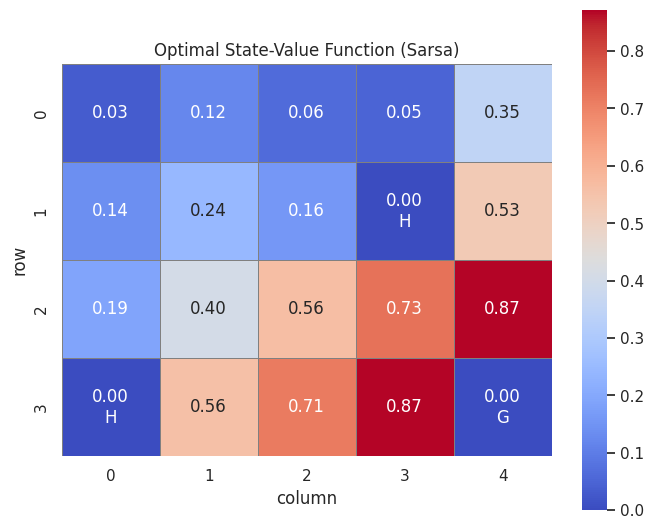

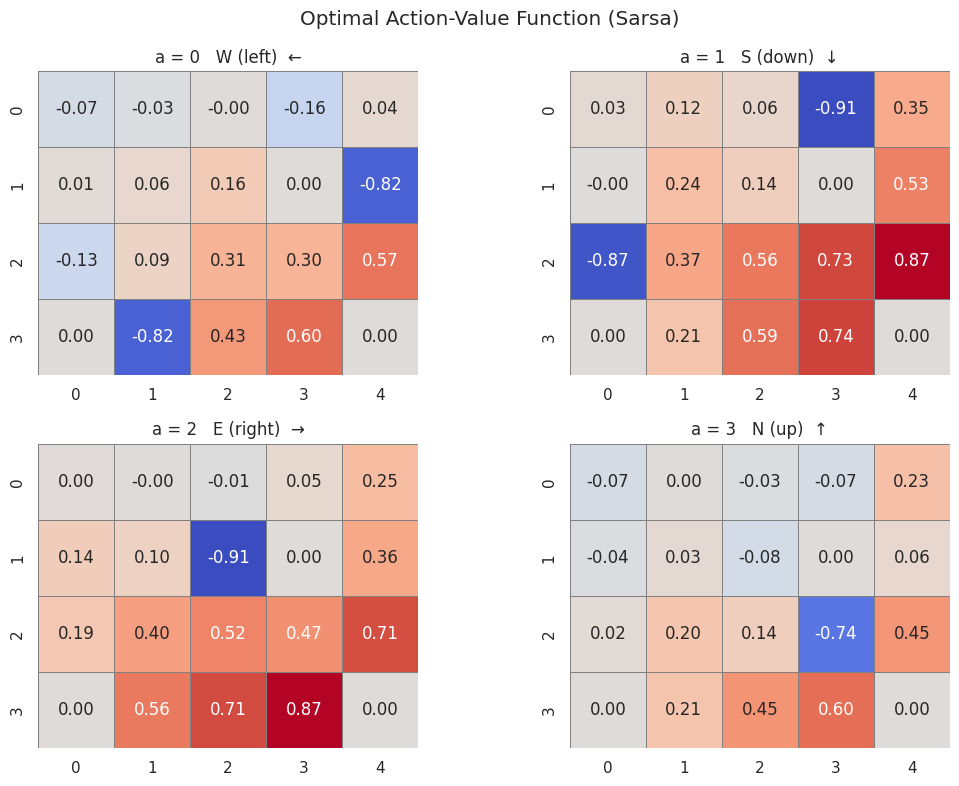

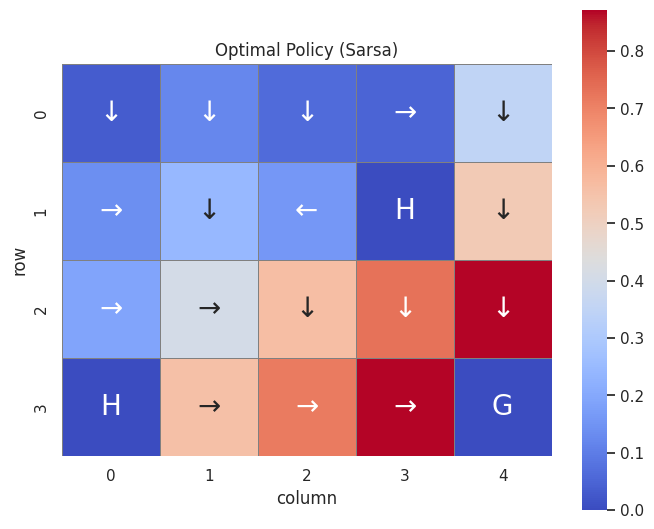

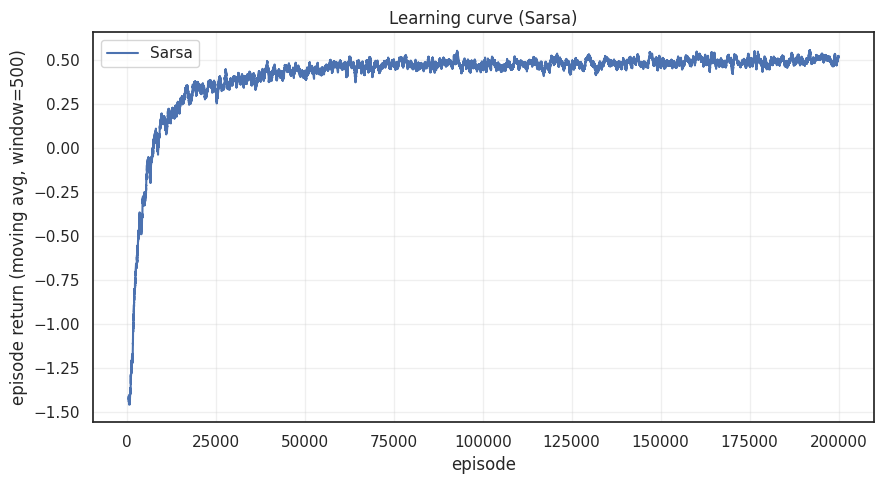

policy match with pi*      : 94%
max |V - V*|               : 0.1157
E[V^pi]  (exact)           : 0.3982   (optimum 0.4093)
value loss E[V*] - E[V^pi] : 0.0112
empirical success rate     : 96.5%

  Sarsa differs from pi* in 1 of 17 non-terminal states:
     state (row,col)   pi*   learned   Q* gap
      7    (1,2)      ↓      ←     0.0698


In [14]:
env.reset(seed=SEED)
set_seed(SEED)

policy_sarsa, Q_sarsa, returns_sarsa = sarsa(
    env, alpha=ALPHA, gamma=GAMMA, num_episodes=N_EPISODES, eps_decay=EPS_DECAY)

print_policy(policy_sarsa, env.unwrapped, "Optimal policy found by Sarsa:")

# ---- the three figures required by the assignment --------------------------
V_sarsa = np.max(Q_sarsa, axis=1)               # V(s) = max_a Q(s,a)
plot_value_function(V_sarsa, "Optimal State-Value Function (Sarsa)", env.unwrapped)
plot_q_function(Q_sarsa, "Optimal Action-Value Function (Sarsa)", env.unwrapped)
plot_policy(policy_sarsa, "Optimal Policy (Sarsa)", env.unwrapped, V=V_sarsa)

plot_learning_curves({"Sarsa": returns_sarsa}, "Learning curve (Sarsa)")

# ---- reference solution + quality of the learned policy --------------------
policy_star, V_star = value_iteration(env, gamma=GAMMA, verbose=False)
_, v_star_mean = exact_policy_value(env, policy_star, GAMMA)
_, v_pi_mean = exact_policy_value(env, policy_sarsa, GAMMA)

env.reset(seed=123)
_, success = evaluate_policy(env, policy_sarsa, gamma=GAMMA, episodes=5000)

print("policy match with pi*      : %.0f%%" % (100 * policy_agreement(policy_sarsa, policy_star, env)))
print("max |V - V*|               : %.4f" % np.max(np.abs(np.max(Q_sarsa, axis=1) - V_star)))
print("E[V^pi]  (exact)           : %.4f   (optimum %.4f)" % (v_pi_mean, v_star_mean))
print("value loss E[V*] - E[V^pi] : %.4f" % (v_star_mean - v_pi_mean))
print("empirical success rate     : %.1f%%" % (100 * success))
print()
report_policy_differences(policy_sarsa, policy_star, V_star, env, "Sarsa")

## 6. Results and conclusions

The policy found by Sarsa:

```
    ↓  ↓  ↓  →  ↓
    →  ↓  ←  H  ↓
    →  →  ↓  ↓  ↓
    H  →  →  →  G
```

| metric | Sarsa | Monte Carlo (Assignment 2) |
|---|---|---|
| policy match with π\* | 94% | 100% |
| `max |V − V*|` | 0.1157 | 0.1344 |
| exact E[V^π] | 0.3982 | 0.4093 |
| **value loss** | **0.0112** | 0.0000 |
| empirical success rate | 96.5% | 95.4% |

(optimum E[V\*] = 0.4093)

| state | (row,col) | π\* | learned | Q\* gap |
|---|---|---|---|---|
| 7 | (1,2) | ↓ | ← | 0.0698 |

The disagreements carry a **Q\* gap** of only a few hundredths, which is exactly
why the value loss stays near zero - these are states where two actions are almost
equally good, not states where Sarsa learned something wrong.

### Sarsa vs Monte Carlo

**Advantages of Sarsa**

* **Much lower variance**: the target $r + \gamma Q(s',a')$ depends on the
  randomness of a *single* transition, whereas the MC return accumulates the
  randomness of an entire episode. The learning curve is visibly smoother.
* **Online / incremental**: it updates after every step instead of waiting for the
  episode to finish, so it also works in continuing tasks and propagates
  information about the holes immediately.
* It exploits the Markov property, which holds exactly in this gridworld.

**Disadvantages of Sarsa**

* The target is **biased** while Q is still wrong, because it bootstraps from its
  own estimates - early updates chase a moving target.
* It converges to $Q^{\pi}$ of the **ε-greedy** policy, not to $Q^*$; only as
  ε → 0 do the two coincide. That is precisely what the GLIE schedule provides,
  and it also explains the residual `max|V − V*| = 0.1157`.
* Being on-policy, it cannot learn about the greedy policy from data generated by
  a different (e.g. purely exploratory, or logged) policy.

### Why Sarsa is the *cautious* algorithm

Sarsa's target averages over what the ε-greedy policy really does - **including
the exploratory mistakes**. A state next to a hole therefore looks genuinely
dangerous to Sarsa, because with probability ε it will actually step into it. This
is the classic *cliff-walking* effect: Sarsa learns the safest policy for an agent
that still explores. Assignment 4 shows the opposite behaviour with Q-Learning.

**Conclusion.** Sarsa reaches an essentially optimal policy
(value loss 0.0112) from the same 200000 episodes as Monte Carlo, with markedly
less noise along the way - the standard bias/variance trade-off between
bootstrapping and full returns, resolved here in favour of bootstrapping.